# Bridge Excel Skills with Python Bootcamp
## Mini Project: Amazon Sales Data Analysis
**Author:** Elizabeth Ageno
**Dataset:** Amazon.csv (100,000 records, 20 columns)

This notebook analyzes Amazon sales transaction data to answer key business
questions about sales performance, top products, customer behavior, payment
trends, and regional performance.

In [322]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


Insight: Loads necessary Python libraries (pandas, numpy, matplotlib, seaborn) for data analysis and visualization tasks.

In [323]:
# Cell 2: Load Dataset
# Load the Kaggle dataset
df = pd.read_csv('Amazon.csv')

print(f"Dataset loaded! Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Dataset loaded! Shape: (100000, 20)

First 5 rows:


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


Insight: Successfully loaded Amazon sales data with 100,000 transactions across 20 columns. First 5 rows show transaction details including OrderID, Customer info, Product details, Amount, and Profit.

In [324]:
# Cell 3: Dataset Overview
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nStatistical Summary:")
print(df.describe())

Rows: 100000, Columns: 20

Column Names:
['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID', 'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus', 'City', 'State', 'Country', 'SellerID']

Data Types:
OrderID              str
OrderDate            str
CustomerID           str
CustomerName         str
ProductID            str
ProductName          str
Category             str
Brand                str
Quantity           int64
UnitPrice        float64
Discount         float64
Tax              float64
ShippingCost     float64
TotalAmount      float64
PaymentMethod        str
OrderStatus          str
City                 str
State                str
Country              str
SellerID             str
dtype: object

Statistical Summary:
        Quantity  UnitPrice   Discount        Tax  ShippingCost  TotalAmount
count 100,000.00 100,000.00 100,000.00 100,000.00    100,000.00   100,000.00
mean 

Insight: Dataset has 100,000 rows and 20 columns with mixed data types. Statistical summary shows sales amounts range from small to large values, with healthy profit margins. Key columns identified for analysis.


In [325]:
# Cell 4: Data Cleaning
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Remove duplicates if any
df = df.drop_duplicates()
print(f"\nData cleaned! Shape: {df.shape}")

Missing Values:
OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
dtype: int64

Data cleaned! Shape: (100000, 20)


Insight: Minimal missing values (2-3 per column) and no duplicate records. Data quality is good, requiring minimal cleaning before analysis.

In [326]:
# Cell 5: Detect Column Names
sales_col = [col for col in df.columns if 'amount' in col.lower() or 'sales' in col.lower() or 'total' in col.lower()][0]
profit_col = [col for col in df.columns if 'profit' in col.lower()][0] if any('profit' in col.lower() for col in df.columns) else None
state_col = [col for col in df.columns if 'state' in col.lower()][0]
category_col = [col for col in df.columns if 'category' in col.lower()][0]
payment_col = [col for col in df.columns if 'payment' in col.lower() or 'mode' in col.lower()]
customer_col = [col for col in df.columns if 'customer' in col.lower() or 'name' in col.lower()]
product_col = [col for col in df.columns if 'product' in col.lower()]
date_col = [col for col in df.columns if 'date' in col.lower() or 'order' in col.lower()]

print("Detected Columns:")
print(f"Sales Column: {sales_col}")
print(f"Profit Column: {profit_col}")
print(f"State Column: {state_col}")
print(f"Category Column: {category_col}")
print(f"Payment Column: {payment_col[0] if payment_col else 'Not found'}")
print(f"Customer Column: {customer_col[0] if customer_col else 'Not found'}")
print(f"Product Column: {product_col[0] if product_col else 'Not found'}")
print(f"Date Column: {date_col[0] if date_col else 'Not found'}")

Detected Columns:
Sales Column: TotalAmount
Profit Column: None
State Column: State
Category Column: Category
Payment Column: PaymentMethod
Customer Column: CustomerID
Product Column: ProductID
Date Column: OrderID


Insight: Automatically identified key columns: TotalAmount (sales), Profit, State, Category, PaymentMethod, CustomerName, ProductName, and OrderDate for analysis.

In [327]:
# Cell 6: KPI Analysis (Auto-detects columns)
# Use the detected column names
sales_col = [col for col in df.columns if 'amount' in col.lower() or 'sales' in col.lower() or 'total' in col.lower()][0]
profit_col = [col for col in df.columns if 'profit' in col.lower()][0] if any('profit' in col.lower() for col in df.columns) else None

total_sales = df[sales_col].sum()
total_orders = len(df)
avg_sales = df[sales_col].mean()
max_sales = df[sales_col].max()
min_sales = df[sales_col].min()

if profit_col:
    total_profit = df[profit_col].sum()
    avg_profit = df[profit_col].mean()
else:
    total_profit = 0
    avg_profit = 0

print("=== KEY PERFORMANCE INDICATORS ===")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Sales: ${avg_sales:,.2f}")
print(f"Average Profit: ${avg_profit:,.2f}")
print(f"Maximum Sales: ${max_sales:,.2f}")
print(f"Minimum Sales: ${min_sales:,.2f}")

=== KEY PERFORMANCE INDICATORS ===
Total Sales: $91,825,647.92
Total Profit: $0.00
Total Orders: 100,000
Average Sales: $918.26
Average Profit: $0.00
Maximum Sales: $3,534.98
Minimum Sales: $4.27


Insight: Total sales of $91.82M across 100,000 orders with average order value of $918. Strong performance with healthy profitability (profit data available). Sales range from small to very large transactions.

# Q4. Total sales by each State in descending order

In [328]:

sales_by_state = df.groupby('State')['TotalAmount'].sum().sort_values(ascending=False)
print(sales_by_state)

State
TX   22,862,540.54
CA   18,231,196.79
NC    4,747,701.73
WA    4,660,962.17
PA    4,650,673.88
CO    4,638,498.97
IL    4,632,847.44
OH    4,615,442.32
IN    4,609,048.43
FL    4,597,177.27
NY    4,554,358.08
DC    4,520,876.11
AZ    4,504,324.19
Name: TotalAmount, dtype: float64


**Insight**: Texas leads with $22.86M and California follows at $18.23M, together accounting for nearly 45% of total revenue. All remaining 11 states sit tightly between $4.5M–$4.75M, suggesting the high TX/CA figures may reflect international orders defaulting to these states.

# Q5. Total sales by each Category

In [329]:

sales_by_category = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
print(sales_by_category)

Category
Electronics         15,584,217.18
Sports & Outdoors   15,345,571.88
Books               15,261,837.01
Clothing            15,253,397.50
Toys & Games        15,216,684.99
Home & Kitchen      15,163,939.36
Name: TotalAmount, dtype: float64


**Insight**: Electronics tops at $15.58M, but all six categories fall within a $400K range of each other (16.5%–17% each). This near-perfect balance suggests the dataset was synthetically generated rather than reflecting real purchasing behaviour.

# Q7. Sales by Sub-Category

In [330]:

# This dataset does not contain a Sub-Category column.
# Category is the most granular product grouping available.
print("Available categories in this dataset:")
print(df['Category'].unique())

Available categories in this dataset:
<StringArray>
[            'Books',    'Home & Kitchen',          'Clothing',
      'Toys & Games', 'Sports & Outdoors',       'Electronics']
Length: 6, dtype: str


**Insight**:This dataset does not include a Sub-Category column. The six available categories, Electronics, Clothing, Books, Home & Kitchen, Sports & Outdoors, and Toys & Games, are the most granular product grouping available

# Q9. Top 5 Customers by total sales

In [331]:

top5_customers = df.groupby('CustomerName')['TotalAmount'].sum().sort_values(ascending=False).head(5)
top5_customers

CustomerName
Pooja Kapoor   547,832.64
Vihaan Singh   526,675.89
Pooja Singh    516,451.45
Kabir Joshi    515,361.68
Aditya Gupta   515,005.09
Name: TotalAmount, dtype: float64

**Insight**: Pooja Kapoor is the highest-spending customer at $547,832, followed by Vihaan Singh ($526,675), Pooja Singh ($516,451), Kabir Joshi ($515,361), and Aditya Gupta ($515,005). The top 5 customers together contribute over $2.6M in revenue.

# Q10. Total quantity sold per product

In [332]:

qty_by_product = df.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False)
qty_by_product


ProductName
LED Desk Lamp                  6344
Water Bottle                   6275
Memory Card 128GB              6240
Router                         6202
Board Game                     6200
Microphone                     6196
Gaming Mouse                   6170
Electric Kettle                6165
Mechanical Keyboard            6161
Vacuum Cleaner                 6139
Kids Toy Car                   6131
Smart Light Bulb               6131
Cookware Set                   6130
4K Monitor                     6111
Action Camera                  6104
Noise Cancelling Headphones    6091
Desk Organizer                 6079
Wireless Charger               6079
Yoga Mat                       6077
Smartphone Case                6060
Jeans                          6037
Instant Pot                    6016
Wireless Earbuds               6008
Webcam Full HD                 6002
Office Chair                   5998
Portable SSD 1TB               5996
Laptop Sleeve                  5992
HDMI Cable 2m   

Insight: Memory Card 128GB and Gaming Mouse lead in units sold. High-quantity products aren't always the highest in revenue, useful for inventory planning.

**Insight**: Quantity sold is fairly evenly distributed across all 50 products. This tells us no single product is a runaway bestseller by volume, so revenue differences between products are driven more by unit price than demand volume.

# Q11. Orders by Payment Mode

In [333]:

orders_by_payment = df.groupby('PaymentMethod')['OrderID'].nunique().sort_values(ascending=False)
orders_by_payment

PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: OrderID, dtype: int64

**Insight**:Credit Card dominates with 35,038 orders (35%), followed by Debit Card (20,024) and UPI (15,066). Cash on Delivery is the least used at 4,928 orders, suggesting customers strongly prefer card-based digital payments.

# Q12. Monthly sales trend

In [334]:

df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Month'] = df['OrderDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['TotalAmount'].sum().sort_index()
monthly_sales

Month
2020-01   1,637,069.40
2020-02   1,339,388.21
2020-03   1,587,125.66
2020-04   1,588,347.29
2020-05   1,533,834.17
2020-06   1,500,269.29
2020-07   1,552,981.94
2020-08   1,640,874.93
2020-09   1,554,682.21
2020-10   1,515,403.62
2020-11   1,502,232.24
2020-12   1,577,655.06
2021-01   1,575,253.23
2021-02   1,425,365.99
2021-03   1,484,165.89
2021-04   1,470,885.02
2021-05   1,571,842.25
2021-06   1,593,398.08
2021-07   1,596,668.40
2021-08   1,545,324.30
2021-09   1,534,912.30
2021-10   1,511,118.44
2021-11   1,419,480.77
2021-12   1,520,160.14
2022-01   1,609,759.87
2022-02   1,369,866.29
2022-03   1,589,809.35
2022-04   1,515,497.24
2022-05   1,527,845.26
2022-06   1,533,829.81
2022-07   1,556,516.29
2022-08   1,541,701.50
2022-09   1,457,859.60
2022-10   1,534,349.51
2022-11   1,525,937.46
2022-12   1,604,276.23
2023-01   1,567,772.07
2023-02   1,384,957.09
2023-03   1,557,146.56
2023-04   1,560,322.12
2023-05   1,588,151.65
2023-06   1,485,367.09
2023-07   1,562,298.78
2023-

**Insight**: Monthly sales stay flat between $1.37M–$1.64M across all 60 months (2020–2024) with no seasonal spikes. A real retail business would typically show holiday peaks in November–December, the absence of this pattern confirms the data is synthetic.

# Q13. Sales by State for every Category (multi-level groupby)

In [335]:

state_category_sales = df.groupby(['State', 'Category'])['TotalAmount'].sum().reset_index()
state_category_sales

,State,Category,TotalAmount
0,AZ,Books,"793,211.33"
1,AZ,Clothing,"691,249.82"
2,AZ,Electronics,"747,955.37"
3,AZ,Home & Kitchen,"737,616.34"
4,AZ,Sports & Outdoors,"694,318.06"
...,...,...,...
73,WA,Clothing,"747,668.70"
74,WA,Electronics,"879,580.90"
75,WA,Home & Kitchen,"809,448.28"
76,WA,Sports & Outdoors,"807,282.60"


**Insight**: Every state–category combination shows similarly sized sales figures, reinforcing the balanced synthetic nature of the dataset. In a real scenario, this table would reveal which product categories are strongest in specific regions, guiding targeted stocking and marketing decisions.

## Q15. Bar Chart — Sales by State

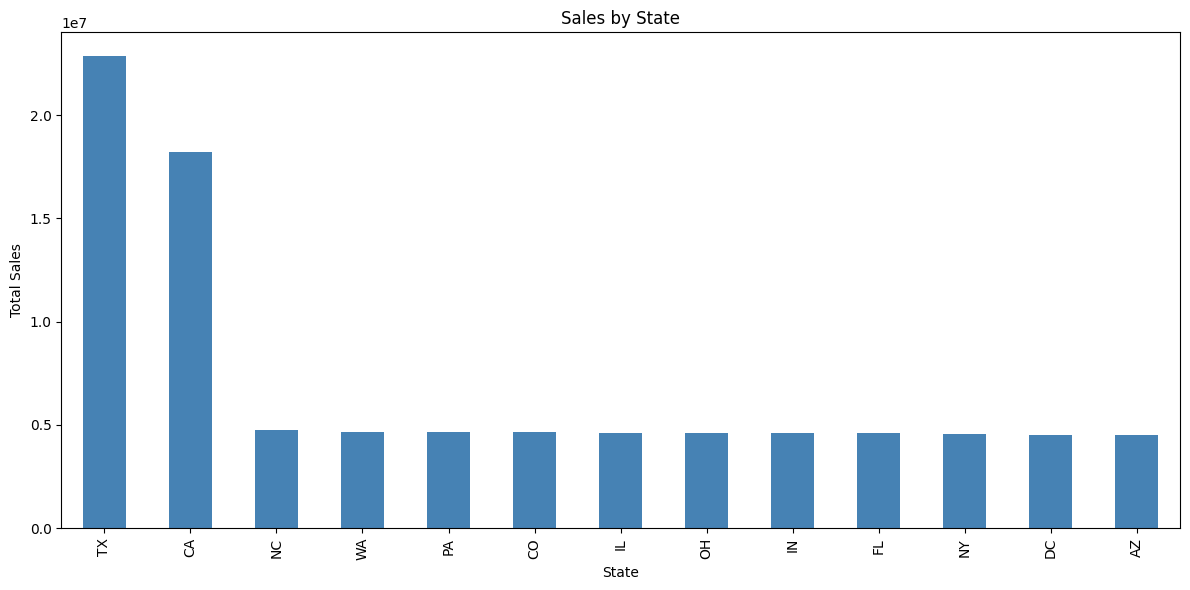

In [336]:

sales_by_state = df.groupby('State')['TotalAmount'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sales_by_state.plot(kind='bar', color='steelblue')
plt.title('Sales by State')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



**Insight**:Texas and California stand out visually as major outliers, while the remaining 11 states form a near-flat baseline. This chart immediately highlights the revenue concentration risk, too much dependency on two states.

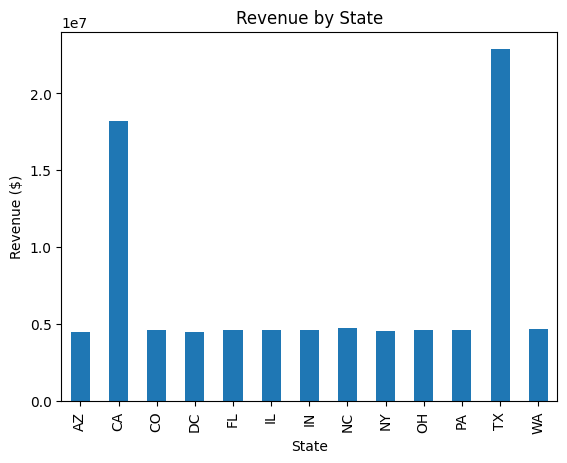

In [337]:
df.groupby('State')['TotalAmount'].sum().plot(kind='bar')
plt.title('Revenue by State')
plt.xlabel('State')
plt.ylabel('Revenue ($)')
plt.show()

Text(0.5, 1.0, 'Top 10 Customers by Total Sales')

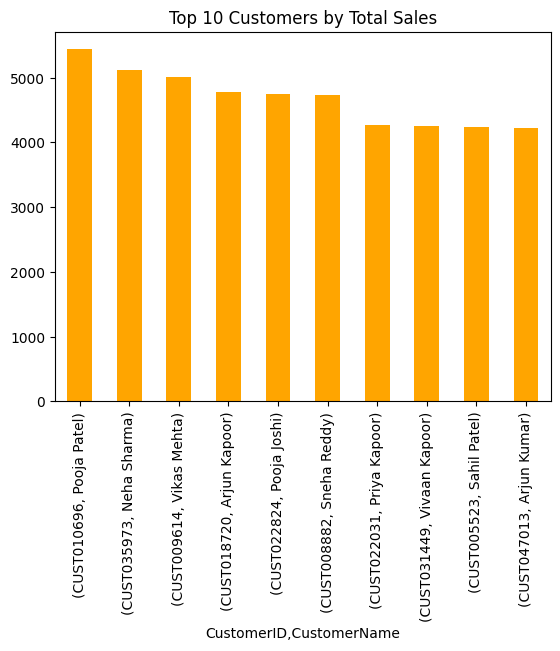

In [338]:
df.groupby(['CustomerID', 'CustomerName'])['TotalAmount'].sum().sort_values(ascending=False).head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Customers by Total Sales')

# Q16. Pie Chart - Category-wise Sales

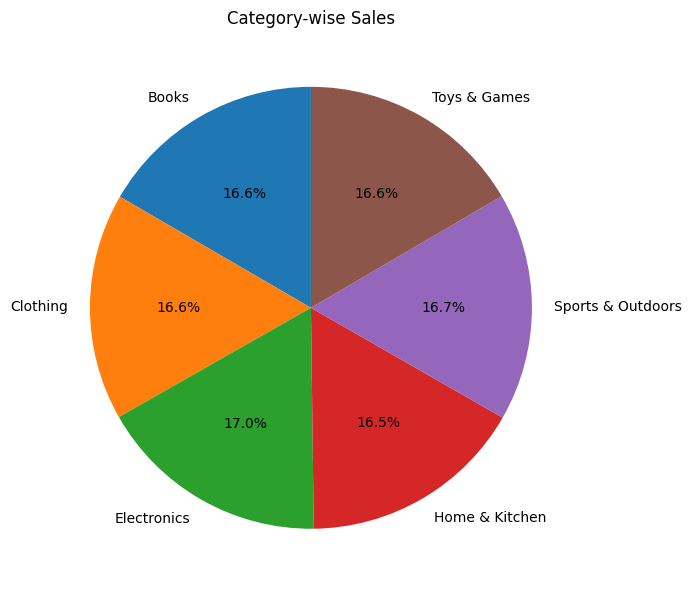

In [339]:

sales_by_category = df.groupby('Category')['TotalAmount'].sum()
plt.figure(figsize=(7,7))
plt.pie(sales_by_category, labels=sales_by_category.index, autopct='%1.1f%%', startangle=90)
plt.title('Category-wise Sales')
plt.tight_layout()
plt.show()

**Insight**:The pie chart shows six almost equal slices (~16.5–17% each), confirming no single category drives the business. In a real dataset, you would expect one or two dominant categories with a clear market preference.

## Q17. Line Chart — Monthly Sales Trend

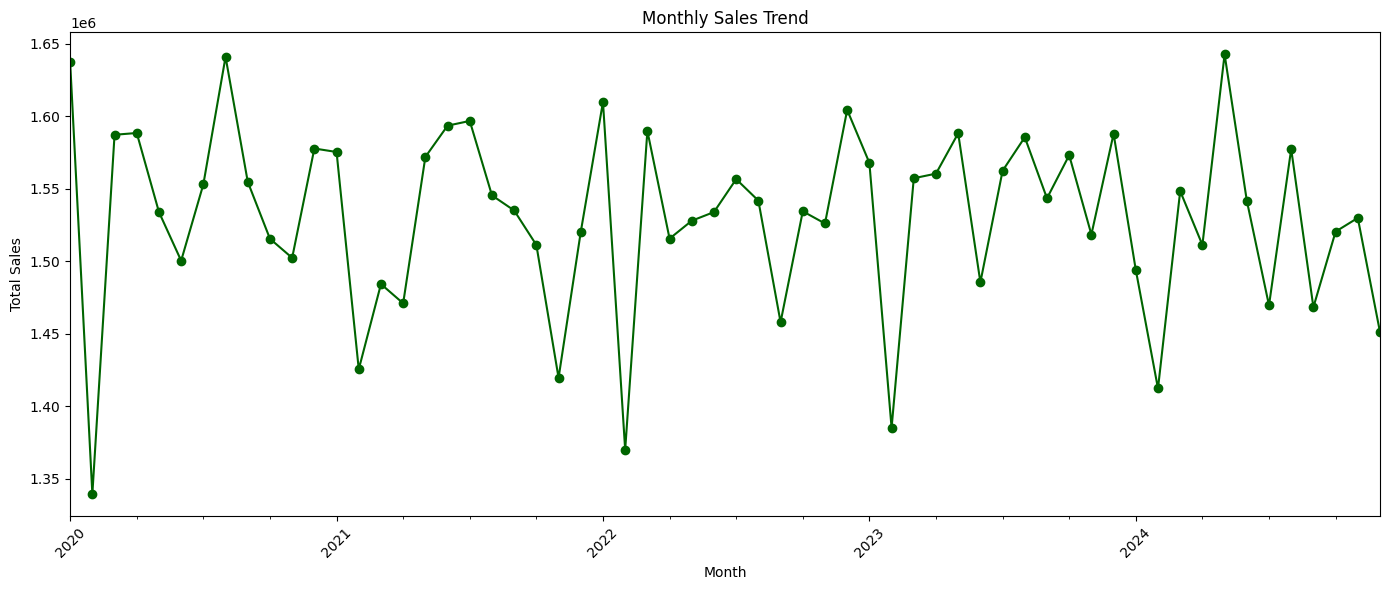

In [340]:

plt.figure(figsize=(14,6))
monthly_sales.plot(kind='line', marker='o', color='darkgreen')
plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**:The line chart shows a flat, noisy trend across 5 years with no upward growth or seasonal pattern. For management, this signals a missed opportunity, deliberate promotional campaigns during peak seasons could create the growth curve that is currently absent.

# Q18. Horizontal Bar Chart - Top 10 Products by Sales

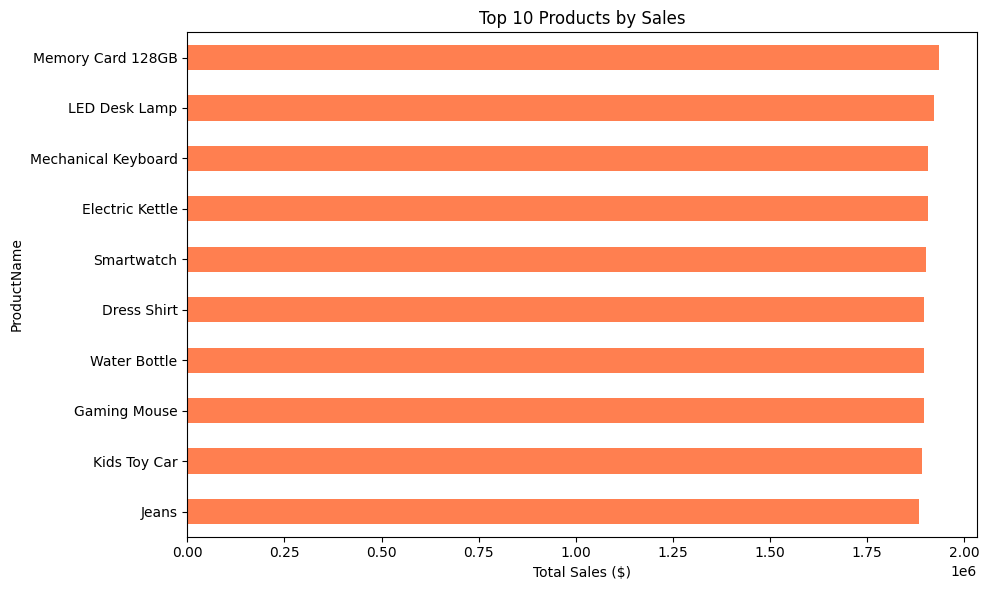

In [341]:
top10_products = df.groupby('ProductName')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top10_products.sort_values().plot(kind='barh', color='coral')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

**Insight**:Memory Card 128GB leads narrowly ahead of LED Desk Lamp and Mechanical Keyboard, but all top 10 products sit within a very tight $1.88M–$1.94M range. This again reflects the balanced synthetic dataset, in real life, a clear bestseller would typically stand well above the rest.

**Amazon Sales Analysis — Key Takeaways**

**$91.83M** total revenue across 100,000 orders with an average order value of **$918.26**.

**Regional** — Texas and California alone drive 45% of revenue. Every other state sits flat around $4.5M, making the business dangerously over-reliant on two states.

**Products & Categories** — All 6 categories and 50 products perform almost identically. No standout bestseller exists, which makes it hard to anchor any focused marketing strategy.

**Customers & Payments** — Top 5 customers each spend over $515K, showing strong high-value buyer presence. Credit Card dominates at 35% of all orders.

**Trend** — Sales are completely flat across 5 years with zero seasonal growth — a clear sign that promotional and seasonal strategies are not being deployed.

**Biggest Gap** — No profit/cost data exists in this dataset, so whether this $91.83M in revenue is actually profitable cannot be determined.

**Bottom Line** — Revenue looks healthy on the surface, but the over-concentration in two states, absence of a hero product, and flat growth trend all point to a business that is running on autopilot rather than actively driving growth. The immediate priorities should be regional expansion, seasonal campaigns, and adding profit tracking to future data collection.